In [1]:
!pip install gymnasium-robotics mujoco transformers scikit-learn
!pip install tensorflow

   ---------------------------------------- 0.0/26.2 MB ? eta -:--:--
   --- ------------------------------------ 2.4/26.2 MB 11.2 MB/s eta 0:00:03
   ------ --------------------------------- 4.2/26.2 MB 11.4 MB/s eta 0:00:02
   ---------- ----------------------------- 6.8/26.2 MB 11.0 MB/s eta 0:00:02
   ------------- -------------------------- 8.9/26.2 MB 11.1 MB/s eta 0:00:02
   ----------------- ---------------------- 11.3/26.2 MB 11.2 MB/s eta 0:00:02
   -------------------- ------------------- 13.4/26.2 MB 11.0 MB/s eta 0:00:02
   ------------------------ --------------- 15.7/26.2 MB 11.1 MB/s eta 0:00:01
   --------------------------- ------------ 17.8/26.2 MB 11.1 MB/s eta 0:00:01
   ------------------------------ --------- 20.2/26.2 MB 11.1 MB/s eta 0:00:01
   ---------------------------------- ----- 22.3/26.2 MB 11.1 MB/s eta 0:00:01
   ------------------------------------- -- 24.6/26.2 MB 11.1 MB/s eta 0:00:01
   ---------------------------------------- 26.2/26.2 MB 10.9 MB/

In [1]:
import gymnasium as gym
import gymnasium_robotics
import numpy as np
import matplotlib.pyplot as plt

gym.register_envs(gymnasium_robotics)

env = gym.make(
    "FetchReach-v4",
    render_mode="rgb_array",
    max_episode_steps=50,
)

images = []
distances = []

def expert_action(obs, gain=8.0, noise=0.15):
    error = obs["desired_goal"] - obs["achieved_goal"]

    action_xyz = gain * error
    action_xyz += np.random.normal(0, noise, size=3)

    action = np.concatenate([action_xyz, [0.0]])
    return np.clip(action, -1.0, 1.0).astype(np.float32)

for episode in range(500):
    #print(f'starting episode {episode}')
    obs, info = env.reset()

    for step in range(50):
        image = env.render()

        # Calculates euclidean distance
        distance = np.linalg.norm(obs["achieved_goal"] - obs["desired_goal"])

        images.append(image)
        distances.append(distance)

        # Algumas trajetórias aleatórias e outras dirigidas
        #if episode < 50:
        # Run random actions
        action = env.action_space.sample()
        #else:
        #    action = expert_action(obs)

        obs, reward, terminated, truncated, info = env.step(action)

        if terminated or truncated:
            break

images = np.asarray(images)
distances = np.asarray(distances)

AdroitHandRelocateDense-v1, AdroitHandHammerDense-v1, AdroitHandDoorDense-v1 environment's reward functions were updated in v1.2.1 without an environment version update. Therefore, use gymnasium-robotics==1.2.0 for v1 reproducibility or use v2 in gymnasium-robotics>=1.4.3. See https://github.com/Farama-Foundation/Gymnasium-Robotics/pull/220 for more details


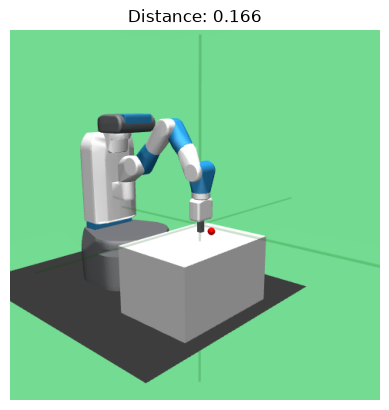

In [2]:
# Show an example
index = np.random.randint(len(images))
plt.imshow(images[index])
plt.title(f"Distance: {distances[index]:.3f}")
plt.axis("off")
plt.show()

In [3]:
import torch
from transformers import AutoImageProcessor, AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(
    "facebook/dinov2-small"
)

model = AutoModel.from_pretrained(
    "facebook/dinov2-small"
).to(device)

model.eval()

for parameter in model.parameters():
    parameter.requires_grad = False

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

C:\Users\gabri\anaconda3\envs\dinov2\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\gabri\.cache\huggingface\hub\models--facebook--dinov2-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

In [4]:
# Embeddings extraction
from PIL import Image
from tqdm.auto import tqdm

def extract_embeddings(images, batch_size=32):
    embeddings = []

    for start in tqdm(range(0, len(images), batch_size)):
        batch_images = [
            Image.fromarray(image)
            for image in images[start:start + batch_size]
        ]

        inputs = processor(
            images=batch_images,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

            batch_embeddings = (
                outputs.last_hidden_state[:, 0]
                .cpu()
                .numpy()
            )

        embeddings.append(batch_embeddings)

    return np.concatenate(embeddings, axis=0)

embeddings = extract_embeddings(images)

print(embeddings.shape)

  0%|          | 0/782 [00:00<?, ?it/s]

(25000, 384)


In [5]:
from sklearn.model_selection import train_test_split

indices = np.arange(len(images))

X_train, X_test, y_train, y_test, train_indices, test_indices = train_test_split(
    embeddings,
    distances,
    indices,
    test_size=0.2,
    random_state=42,
)

In [70]:
# Print graphical results
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
pd.set_option("display.max_columns", None)

def regression_plots(model, X_test, y_test, y_pred, model_name):
    residuals = y_test - y_pred
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Actual vs Predicted
    ax = axes[0]
    ax.scatter(y_test, y_pred, alpha=0.6)
    ax.ticklabel_format(style="sci", axis="both", scilimits=(0, 0))
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        color="red",
        linestyle="--"
    )
    ax.set_title("Actual vs Predicted")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

    # Residual Plot
    ax = axes[1]
    ax.ticklabel_format(style="sci", axis="both", scilimits=(0, 0))
    ax.scatter(y_pred, residuals, alpha=0.6)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_title("Residual Plot")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Residual")

    # Residual Histogram
    ax = axes[2]
    ax.ticklabel_format(style="sci", axis="both", scilimits=(0, 0))
    ax.hist(residuals, bins=30)
    ax.axvline(0, color="red", linestyle="--")
    ax.set_title("Residual Distribution")
    ax.set_xlabel("Residual")
    ax.set_ylabel("Frequency")

    plt.suptitle(model_name, fontsize=16)

    plt.tight_layout()

    plt.show()

def show_predictions(X_test, y_test, y_pred, rows=5, cols=5):
  # Show predicted values
  sample_idx = np.random.choice(len(X_test), rows * cols, replace=False)
  fig, axes = plt.subplots(rows, cols, figsize=(2.5*cols, 2.5*rows))

  for ax, idx in zip(axes.ravel(), sample_idx):
      original_idx = test_indices[idx]
      img = images[original_idx]

      true_distance = y_test[idx]
      pred_distance = y_pred[idx]
      error = abs(true_distance - pred_distance)

      ax.imshow(img)
      ax.axis("off")
      ax.set_title(
          f"Real: {true_distance:.3f} m\n"
          f"Pred.: {pred_distance:.3f} m\n"
          f"Error: {error:.3f} m",
          fontsize=9
      )

  plt.tight_layout()
  plt.show()

In [71]:
metrics = {
    "MAE": np.zeros(5),
    "MAPE": np.zeros(5),
    "RMSE": np.zeros(5),
    "R2": np.zeros(5),
}

Random Forest

In [72]:
from sklearn.ensemble import RandomForestRegressor

#RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    n_jobs=-1,
    random_state=0
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

i = 0
metrics["MAE"][i] = mean_absolute_error(y_test, y_pred)
metrics["MAPE"][i] = mean_absolute_percentage_error(y_test, y_pred)
metrics["RMSE"][i] = np.sqrt(mean_squared_error(y_test, y_pred))
metrics["R2"][i] = r2_score(y_test, y_pred)

print('MAE:\t%.4f' % metrics["MAE"][i])
print('MAPE:\t%.4f' % metrics["MAPE"][i])
print('RMSE:\t%.4f' % metrics["RMSE"][i])
print('R²: \t%.4f' % metrics["R2"][i])

# Print numerical results
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
comparison["Error"] = comparison["Actual"] - comparison["Predicted"]

print("\n")
comparison.head(5)

MAE:	0.0414
MAPE:	0.3010
RMSE:	0.0526
R²: 	0.5790




,Actual,Predicted,Error
0,0.324240,0.258235,0.066005
1,0.203942,0.159531,0.044411
2,0.228037,0.156373,0.071665
3,0.159687,0.215612,-0.055925
4,0.305795,0.232246,0.073549


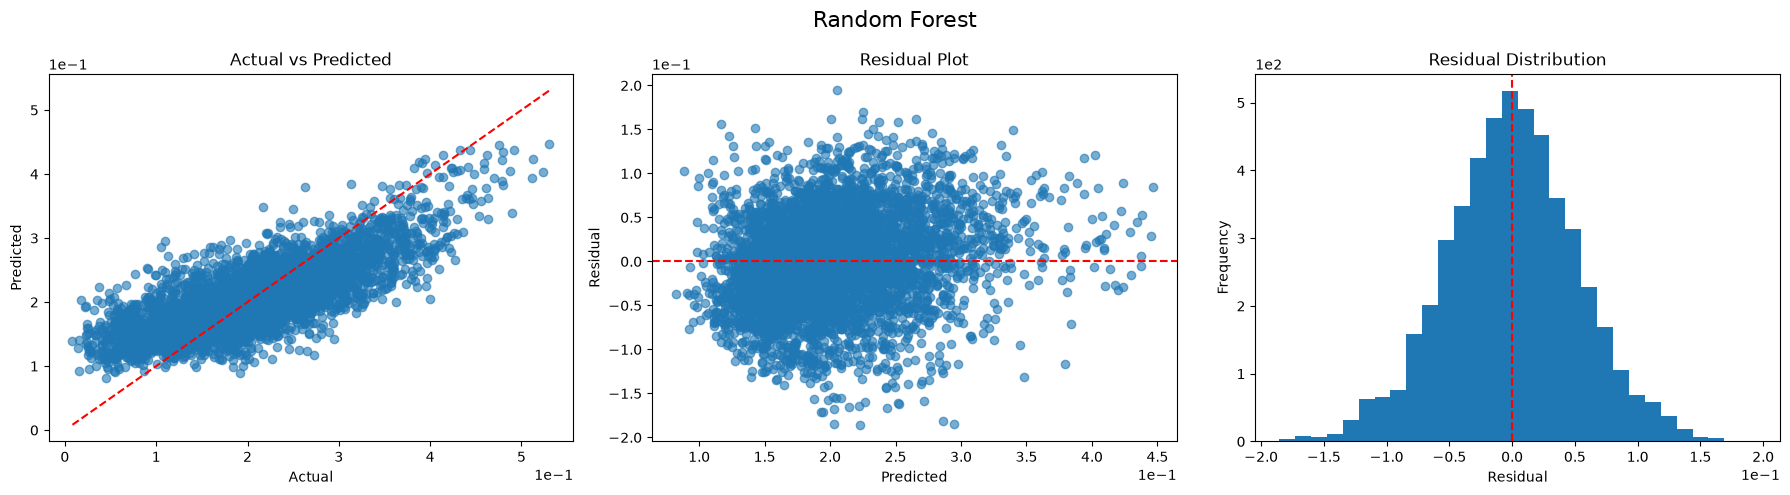

In [73]:
regression_plots(rf, X_test, y_test, y_pred, "Random Forest")

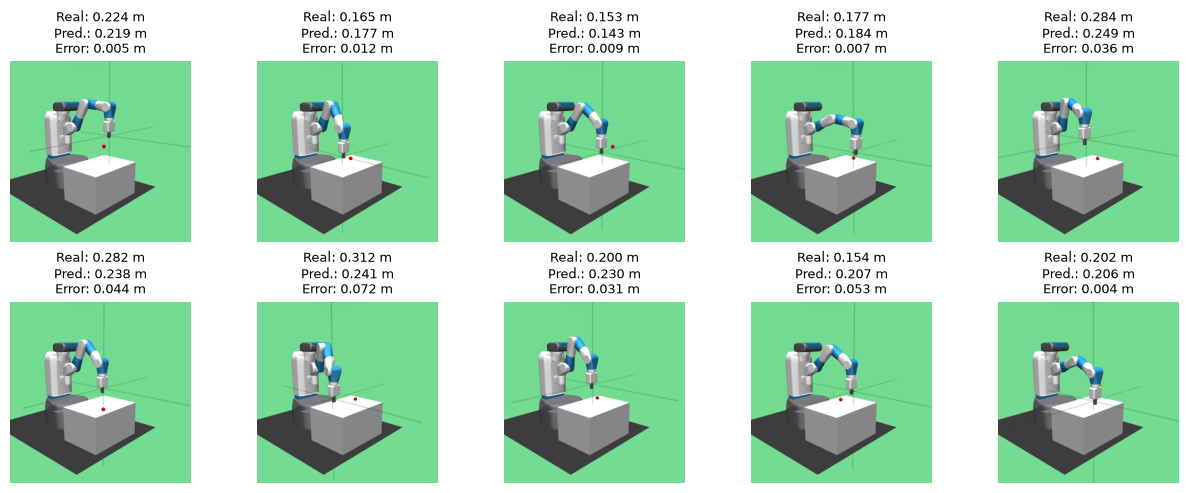

In [74]:
show_predictions(X_test, y_test, y_pred, 2, 5)

XGBoost

In [75]:
# Train XGBoost model
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.04,
    objective="reg:squarederror",
    random_state=0,
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

i = 1
metrics["MAE"][i] = mean_absolute_error(y_test, y_pred)
metrics["MAPE"][i] = mean_absolute_percentage_error(y_test, y_pred)
metrics["RMSE"][i] = np.sqrt(mean_squared_error(y_test, y_pred))
metrics["R2"][i] = r2_score(y_test, y_pred)

print('MAE:\t%.4f' % metrics["MAE"][i])
print('MAPE:\t%.4f' % metrics["MAPE"][i])
print('RMSE:\t%.4f' % metrics["RMSE"][i])
print('R²: \t%.4f' % metrics["R2"][i])

# Print numerical results
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
comparison["Error"] = comparison["Actual"] - comparison["Predicted"]

print("\n")
comparison.head(5)

MAE:	0.0388
MAPE:	0.2735
RMSE:	0.0492
R²: 	0.6321




,Actual,Predicted,Error
0,0.324240,0.238572,0.085668
1,0.203942,0.170546,0.033397
2,0.228037,0.142032,0.086006
3,0.159687,0.207159,-0.047472
4,0.305795,0.265626,0.040169


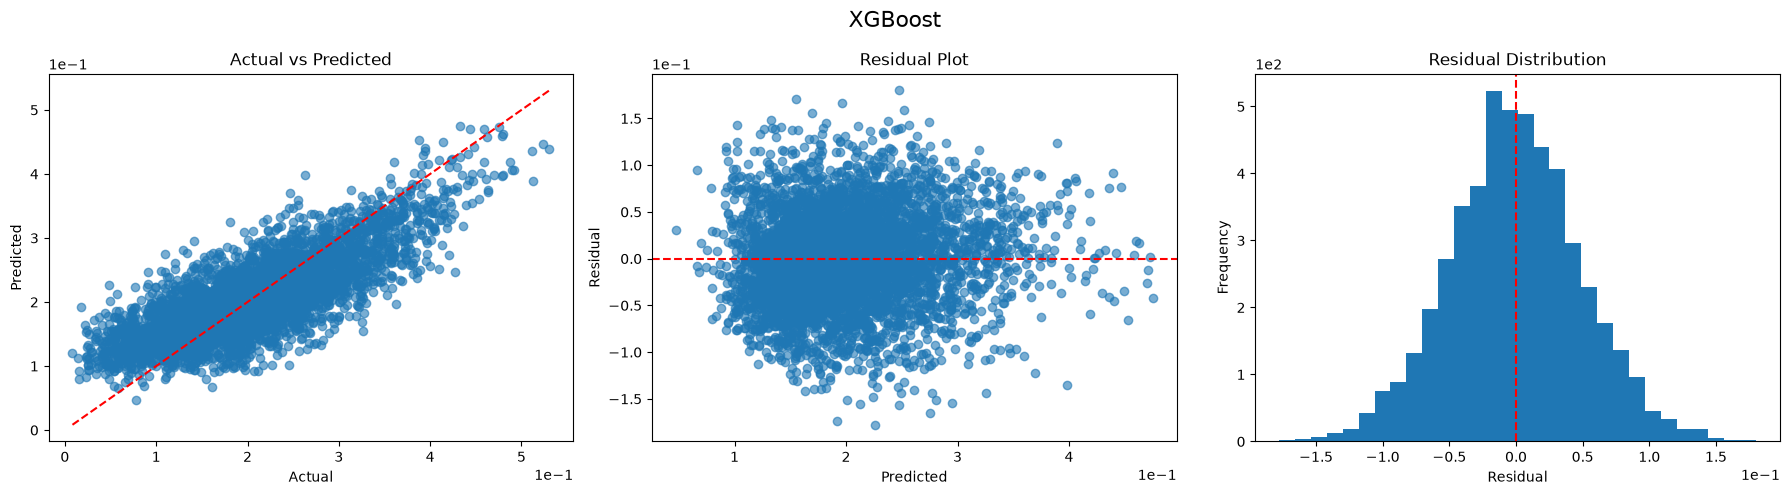

In [76]:
regression_plots(rf, X_test, y_test, y_pred, "XGBoost")

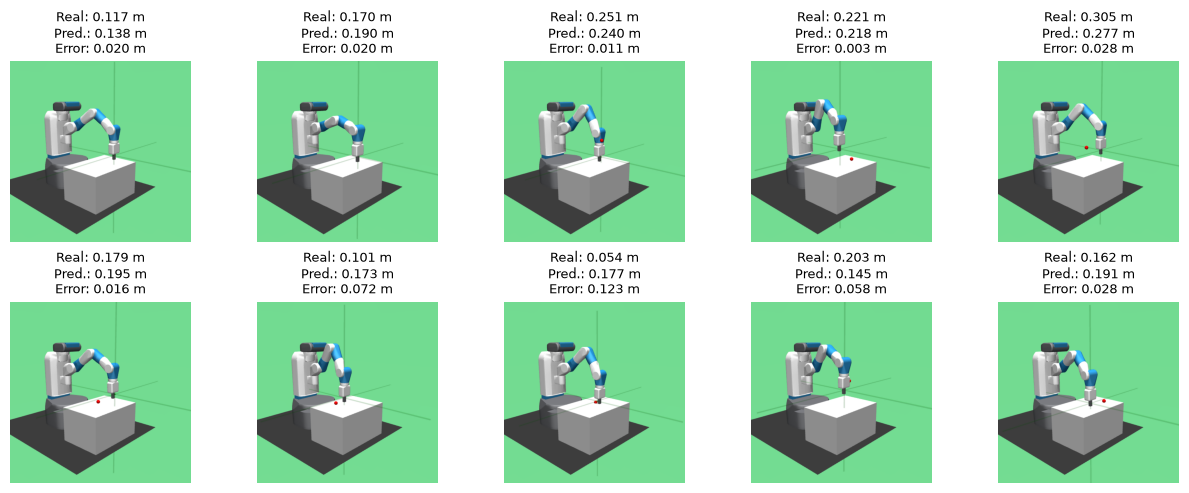

In [77]:
show_predictions(X_test, y_test, y_pred, 2, 5)

Gradient Boosting

In [78]:
from sklearn.ensemble import GradientBoostingRegressor

# Gradient Boosting
reg = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.04,
    max_depth=3,
    loss="huber",
    random_state=0
)

reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

i = 2
metrics["MAE"][i] = mean_absolute_error(y_test, y_pred)
metrics["MAPE"][i] = mean_absolute_percentage_error(y_test, y_pred)
metrics["RMSE"][i] = np.sqrt(mean_squared_error(y_test, y_pred))
metrics["R2"][i] = r2_score(y_test, y_pred)

print('MAE:\t%.4f' % metrics["MAE"][i])
print('MAPE:\t%.4f' % metrics["MAPE"][i])
print('RMSE:\t%.4f' % metrics["RMSE"][i])
print('R²: \t%.4f' % metrics["R2"][i])

# Print numerical results
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
comparison["Error"] = comparison["Actual"] - comparison["Predicted"]

print("\n")
comparison.head(5)

MAE:	0.0439
MAPE:	0.3159
RMSE:	0.0556
R²: 	0.5290




,Actual,Predicted,Error
0,0.324240,0.225024,0.099215
1,0.203942,0.161821,0.042122
2,0.228037,0.146296,0.081742
3,0.159687,0.205661,-0.045973
4,0.305795,0.246333,0.059462


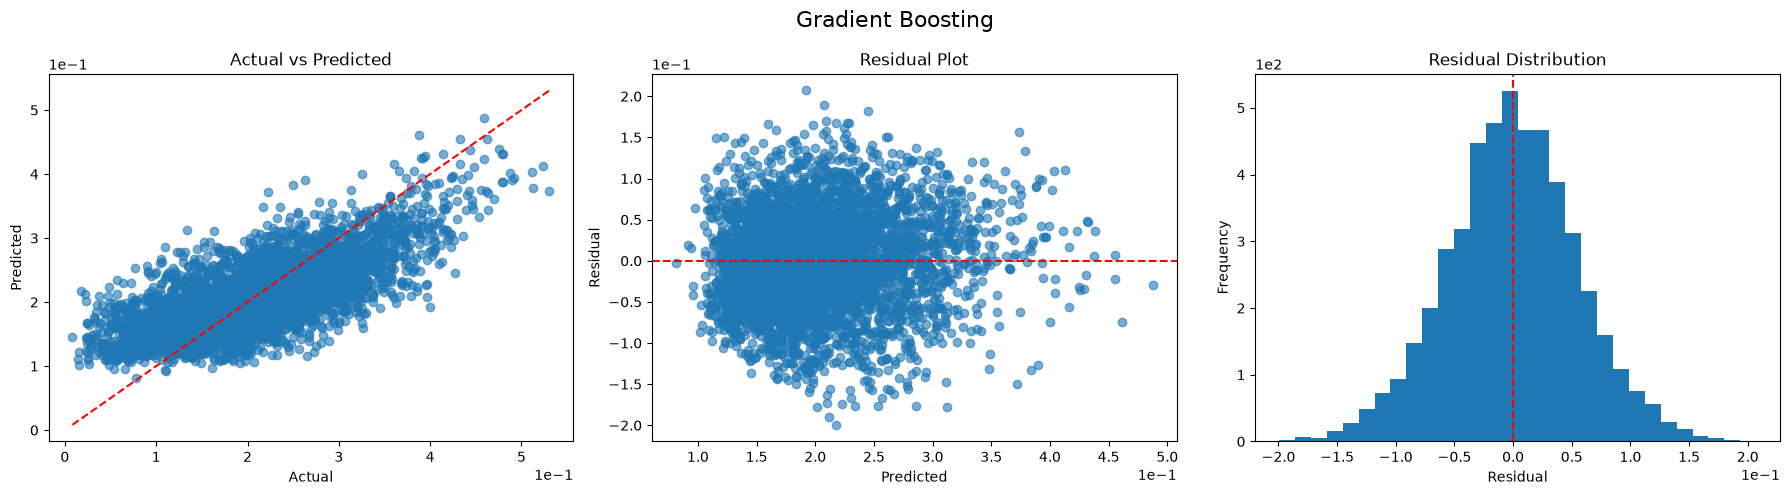

In [79]:
regression_plots(rf, X_test, y_test, y_pred, "Gradient Boosting")

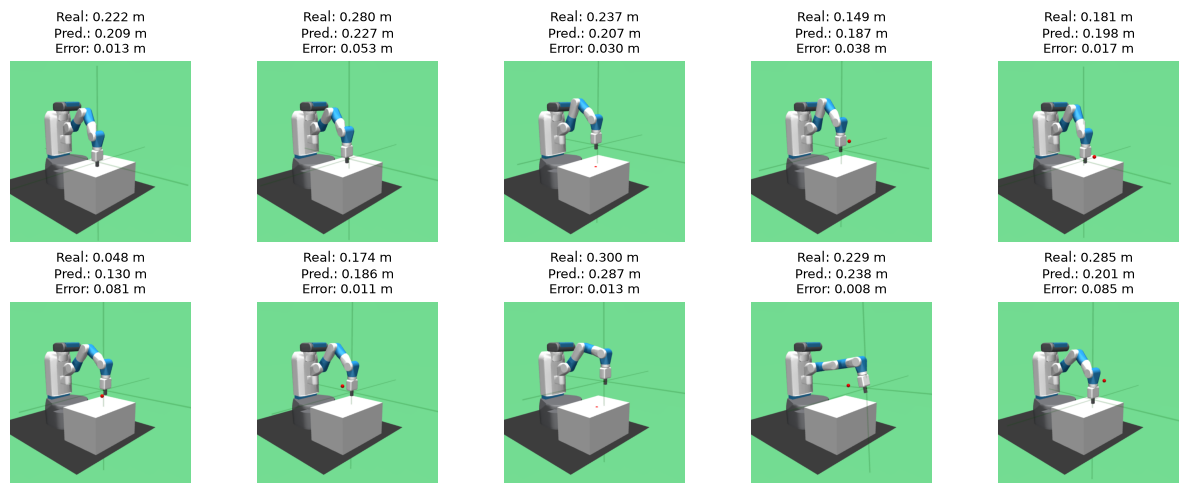

In [80]:
show_predictions(X_test, y_test, y_pred, 2, 5)

LightGBM

In [81]:
from lightgbm import LGBMRegressor

# LightGBM
lgbm = LGBMRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.04,
    random_state=0,
    verbose=-1
)

lgbm.fit(X_train, y_train)

y_pred = lgbm.predict(X_test)

i = 3
metrics["MAE"][i] = mean_absolute_error(y_test, y_pred)
metrics["MAPE"][i] = mean_absolute_percentage_error(y_test, y_pred)
metrics["RMSE"][i] = np.sqrt(mean_squared_error(y_test, y_pred))
metrics["R2"][i] = r2_score(y_test, y_pred)

print('MAE:\t%.4f' % metrics["MAE"][i])
print('MAPE:\t%.4f' % metrics["MAPE"][i])
print('RMSE:\t%.4f' % metrics["RMSE"][i])
print('R²: \t%.4f' % metrics["R2"][i])

# Print numerical results
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
comparison["Error"] = comparison["Actual"] - comparison["Predicted"]

print("\n")
comparison.head(5)

MAE:	0.0448
MAPE:	0.3267
RMSE:	0.0565
R²: 	0.5149




,Actual,Predicted,Error
0,0.324240,0.233361,0.090879
1,0.203942,0.160588,0.043355
2,0.228037,0.163806,0.064232
3,0.159687,0.221890,-0.062203
4,0.305795,0.236494,0.069301


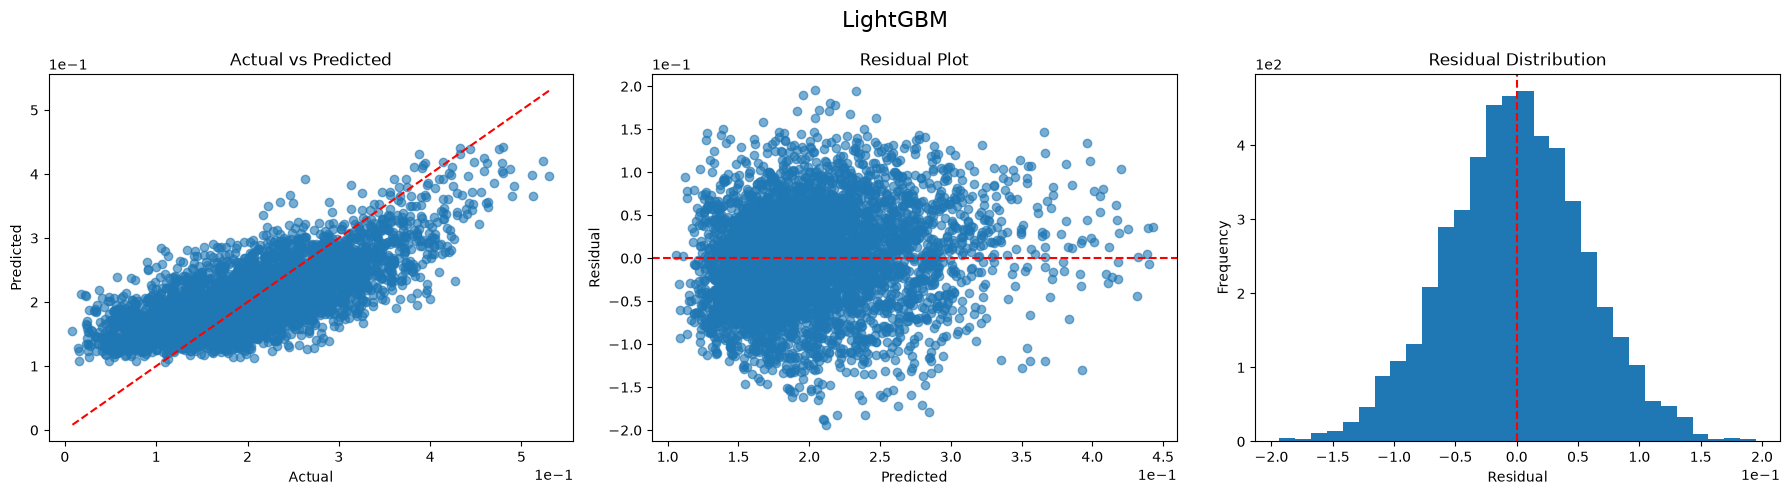

In [82]:
regression_plots(rf, X_test, y_test, y_pred, "LightGBM")

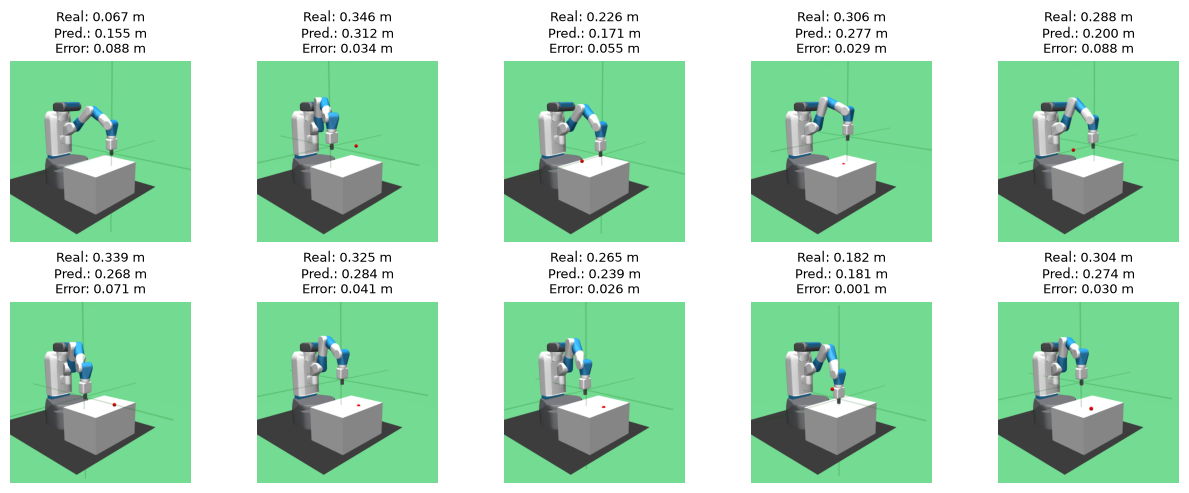

In [83]:
show_predictions(X_test, y_test, y_pred, 2, 5)

MultiLayer Perceptron (MLP)

In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)  # regression
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

C:\Users\gabri\anaconda3\envs\dinov2\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [85]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

In [86]:
y_pred = model.predict(X_test_scaled).flatten()

i = 4
metrics["MAE"][i] = mean_absolute_error(y_test, y_pred)
metrics["MAPE"][i] = mean_absolute_percentage_error(y_test, y_pred)
metrics["RMSE"][i] = np.sqrt(mean_squared_error(y_test, y_pred))
metrics["R2"][i] = r2_score(y_test, y_pred)

print('MAE:\t%.4f' % metrics["MAE"][i])
print('MAPE:\t%.4f' % metrics["MAPE"][i])
print('RMSE:\t%.4f' % metrics["RMSE"][i])
print('R²: \t%.4f' % metrics["R2"][i])

# Print numerical results
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
comparison["Error"] = comparison["Actual"] - comparison["Predicted"]

print("\n")
comparison.head(5)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 914us/step
MAE:	0.0332
MAPE:	0.2243
RMSE:	0.0426
R²: 	0.7239




,Actual,Predicted,Error
0,0.324240,0.243953,0.080287
1,0.203942,0.205220,-0.001277
2,0.228037,0.119985,0.108053
3,0.159687,0.180375,-0.020687
4,0.305795,0.264465,0.041330


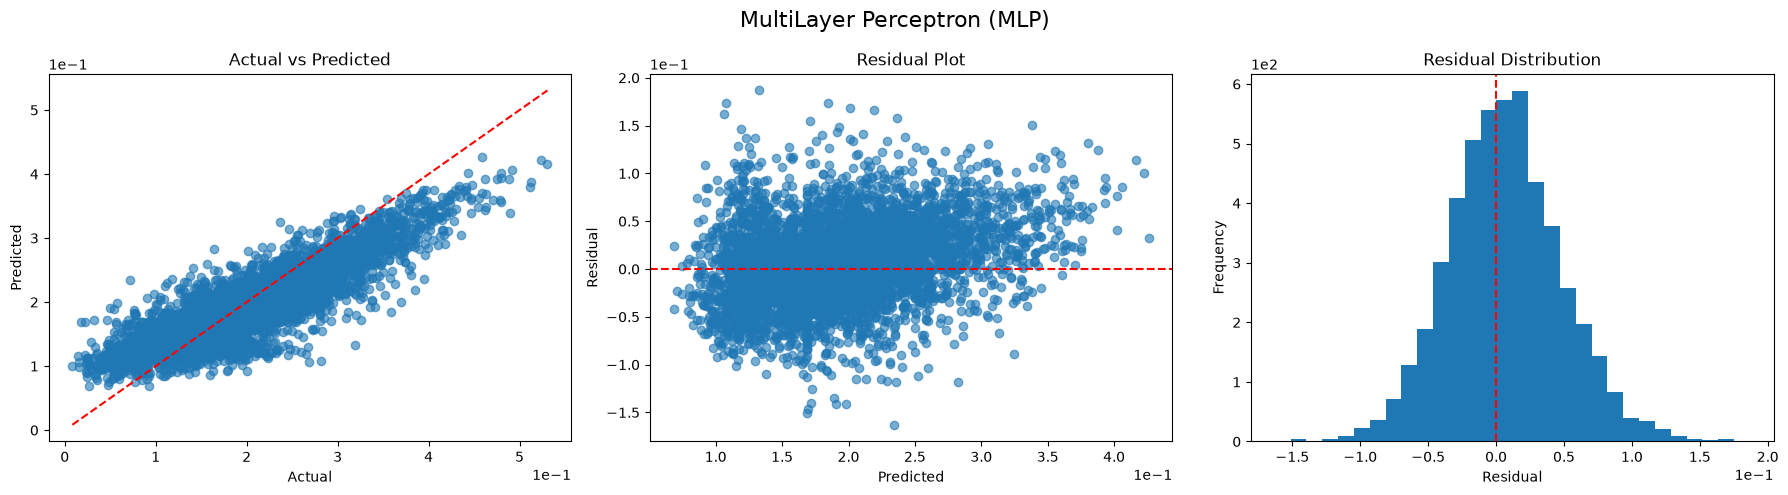

In [87]:
regression_plots(rf, X_test, y_test, y_pred, "MultiLayer Perceptron (MLP)")

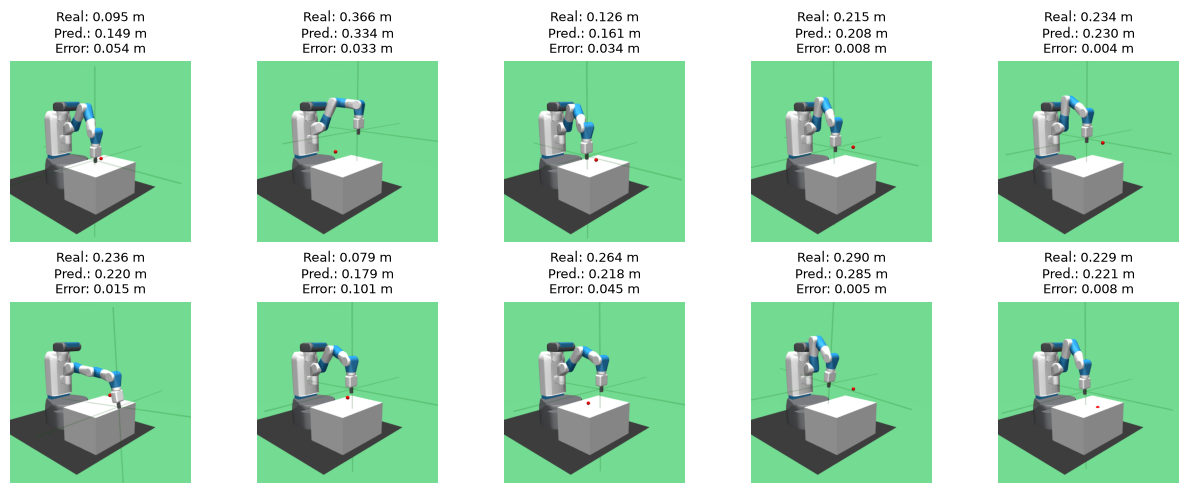

In [88]:
show_predictions(X_test, y_test, y_pred, 2, 5)

Comparison of results

In [89]:
import pandas as pd

model_names = [
    'Random Forest',
    'XGBoost',
    'Gradient Boosting',
    'LightGBM',
    'MLP'
]

results = pd.DataFrame(
    {
        "MAE": metrics["MAE"],
        "MAPE": metrics["MAPE"],
        "RMSE": metrics["RMSE"],
        "R2": metrics["R2"],
    },
    index=model_names,
)

results.index.name = "Model"

results.round({
    "MAE": 4,
    "MAPE": 4,
    "RMSE": 4,
    "R2": 4,
})

,MAE,MAPE,RMSE,R2
Model,,,,
Random Forest,0.0414,0.3010,0.0526,0.5790
XGBoost,0.0388,0.2735,0.0492,0.6321
Gradient Boosting,0.0439,0.3159,0.0556,0.5290
LightGBM,0.0448,0.3267,0.0565,0.5149
MLP,0.0332,0.2243,0.0426,0.7239
